<a href="https://colab.research.google.com/github/ollihansen90/Mathe-SH/blob/main/Artificial_Life.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Artificial Life
- Die letzten Wochen: Drei "Elternzellen"
- Heute: beliebig viele "Elternzellen"
- Später: beliebig viele Schritte in Vergangenheit
- Packages Numpy für "Rechnung", matplotlib für "Malen"

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Recap: Das Package Numpy
- nutzt in erster Linie Numpy-Arrays
- wie Listen in Python, nur dass wir jetzt damit rechnen können
- jede Liste mit Zahlen kann in ein Numpy-Array umgewandelt werden
- später (so ab Klasse 11): "Numpy-Array=Vektoren"

### Praktische Funktionen zur Initialisierung
- `zeros`
- `ones`
- `arange`
- `random.rand`


In [3]:
print("Liste vs. Numpy-Array:")
liste = [4,3,7,7,2,5]
print(liste)
liste_als_nparray = np.array(liste)
print(liste_als_nparray)

# Beispiel: np.arange
print("Beispiel np.arange")
liste = list(range(10))
np_array = np.arange(10)
print(liste)
print(np_array)

# weitere praktische Beispiele
print("Mehr Numpy:")
np_array_1 = np.zeros(10) # Liste mit Nullen
print(np_array_1)
np_array_2 = np.ones(10) # Liste mit Einsen
print(np_array_2)
np_array_3 = np.random.rand(10) # Liste mit zufälligen Werten zw. 0 und 1 (gleichverteilt)
print(np_array_3)

Liste vs. Numpy-Array:
[4, 3, 7, 7, 2, 5]
[4 3 7 7 2 5]
Beispiel np.arange
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0 1 2 3 4 5 6 7 8 9]
Mehr Numpy:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0.5327574  0.39773629 0.12115795 0.1357197  0.18826217 0.2734801
 0.09709576 0.64882204 0.05283721 0.35112622]


### Rechnen mit Numpy

In [24]:
print(np_array)
print("Addition:")
print(np_array+21)
print("Multiplikation:")
print(np_array*5)
print([1,3,7,2]*5)
print("Vergleich:")
print(np_array>5) # "nur Einträge größer als 5"
print(np_array%2==0) # "nur gerade Einträge"
print("Summe zweier Arrays:")
print(np_array+np_array_3)
print("Produkt zweier Arrays:")
print(np_array*np_array_3)
print("Summe eines Arrays:")
print(np.sum(np_array))

[0 1 2 3 4 5 6 7 8 9]
Addition:
[21 22 23 24 25 26 27 28 29 30]
Multiplikation:
[ 0  5 10 15 20 25 30 35 40 45]
[1, 3, 7, 2, 1, 3, 7, 2, 1, 3, 7, 2, 1, 3, 7, 2, 1, 3, 7, 2]
Vergleich:
[False False False False False False  True  True  True  True]
[ True False  True False  True False  True False  True False]
Summe zweier Arrays:
[0.12343184 1.33482261 2.324634   3.89142404 4.8466468  5.49012919
 6.33185136 7.54126106 8.32950501 9.56029327]
Produkt zweier Arrays:
[0.         0.33482261 0.64926799 2.67427211 3.38658719 2.45064597
 1.99110813 3.78882739 2.63604008 5.04263945]
Summe eines Arrays:
45


### Indexing
- genau wie bei normalen Python-Listen, nur mehr Möglichkeiten
- wichtig: `copy`

In [29]:
# Indexing (wie bei Listen)
print(np_array[5])
print(np_array[-3])
print(np_array[2:6])
print(np_array[2:9:3])

# Sehr praktisch: Indexing über Boolean
neues_array = np_array.copy() # Achtung! Wird sonst überschrieben!
neues_array[neues_array<4] = -1
print(neues_array)

5
7
[-1 -1  4  5]
[-1  5  8]
[-1 -1 -1 -1  4  5  6  7  8  9]


## Artificial Life: Randbedingungen
- Wie bisher: periodisch
- jetzt: Schreibe Funktion, um Rand hinzuzufügen
- "Padding"
- `conactenate` heißt "anhängen"

In [4]:
def rand(array, breite):
    anfang = array[-breite:]
    ende = array[:breite]
    return np.concatenate([anfang, array, ende])

def rand(array, breite):
    return np.pad(array, breite, mode="wrap")

### Elternblock
- Hier neu: eine Liste wird "verschoben" und aneinandergehängt

In [5]:
def elternblock(welt, breite):
    welt_rand = rand(welt, breite)
    #print(welt_rand)
    output = []
    n_eltern = 2*breite+1
    for i in range(n_eltern):
        output.append(welt_rand[i:i+len(welt)])
    return np.stack(output)

welt = np.arange(10)
print(elternblock(welt, 2))

[[8 9 0 1 2 3 4 5 6 7]
 [9 0 1 2 3 4 5 6 7 8]
 [0 1 2 3 4 5 6 7 8 9]
 [1 2 3 4 5 6 7 8 9 0]
 [2 3 4 5 6 7 8 9 0 1]]


### Die Welt simulieren
#### Schritt 1: Parameter
(kurze Beschreibung von `groesse`, `n_epochs`, `nachbarschaft`, `seed`)
#### Schritt 2: Die Welt initialisieren (`t=0`)
mit `np.zeros(groesse)` oder `np.random.rand(groesse)`
#### Schritt 3: Die Regeln
Für eine Nachbarschaft von 3 sind es 8 Regeln, für 5 sind es schon 32, für 7 sind es 128. Niemand möchte 128 Regeln "per Hand" bestimmen, daher wieder mit `np.random.rand` und `2**groesse` Einträge
#### Schritt 4: Simulation
Im Prinzip genau wie vorher, nur werden jetzt die "Elternzeilen" gewichtet aufaddiert (später: Das ist genau das Prinzip der Faltung!)
#### Schritt 5: Plotten
Einfach mit `matplotlib` plotten. Wird vorgegeben 🙂

[0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1.
 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0.
 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0.
 0. 0. 0. 1. 0. 0. 1. 0.]


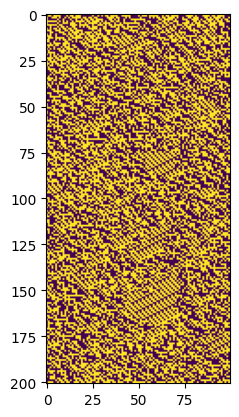

In [19]:
# Schritt 1: Definiere Parameter
groesse = 100
n_epochs = 200
nachbarschaft = 7 # "wie viele hatten wir sonst immer?" -> 3
np.random.seed(15)

# Schritt 2: initialisiere Welt (z.B. mit np.random.rand)
welt = np.random.rand(groesse)
welt[welt>0.5] = 1
welt[welt<=0.5] = 0
verlauf = [welt]

# Schritt 3: definiere Regeln
regeln = np.random.rand(2**nachbarschaft)
regeln[regeln>0.5] = 1
regeln[regeln<=0.5] = 0
print(regeln)
#regeln = [0,1,1,0,1,0,0,0]
# z.B. eltern 011 -> 0*1+1*2+1*4=6 -> Siehe an Stelle 6 von "regeln" nach

#print(len(elternblock(verlauf[-1], nachbarschaft//2)))
# Schritt 4: Simulation
for _ in range(n_epochs):
    update = np.zeros(len(welt))
    welt_neu = np.zeros(len(welt))
    eltern = elternblock(verlauf[-1], nachbarschaft//2)
    for i in range(nachbarschaft):
        update += 2**i*eltern[i]
    for i in range(len(regeln)):
        welt_neu[update==i] = regeln[i]
    verlauf.append(welt_neu)

# Schritt 5: Plotte Verlauf
plt.figure()
plt.imshow(verlauf)
plt.show()

### Bonus: Sonderregeln mit Anzahl "lebender" Eltern
Einziger Unterschied ist Anzahl der Regeln (Zeile 14, `nachbarschaft` statt `2**nachbarschaft`) und keine Gewichtung mit `2**i` für `update`

[1. 1. 0. 0. 1. 0. 1.]


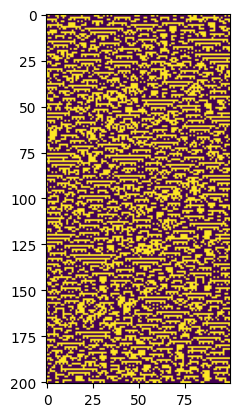

In [38]:
# Schritt 1: Definiere Parameter
groesse = 100
n_epochs = 200
nachbarschaft = 7 # "wie viele hatten wir sonst immer?" -> 3
np.random.seed(13)

# Schritt 2: initialisiere Welt (z.B. mit np.random.rand)
welt = np.random.rand(groesse)
welt[welt>0.5] = 1
welt[welt<=0.5] = 0
verlauf = [welt]

# Schritt 3: definiere Regeln
regeln = np.random.rand(nachbarschaft)
regeln[regeln>0.5] = 1
regeln[regeln<=0.5] = 0
print(regeln)
#regeln = [0,1,1,0,1,0,0,0]
# z.B. eltern 011 -> 0*1+1*2+1*4=6 -> Siehe an Stelle 6 von "regeln" nach

#print(len(elternblock(verlauf[-1], nachbarschaft//2)))
# Schritt 4: Simulation
for _ in range(n_epochs):
    welt_neu = np.zeros(len(welt))
    eltern = elternblock(verlauf[-1], nachbarschaft//2)
    update = np.sum(eltern, axis=0)
    for i in range(len(regeln)):
        welt_neu[update==i] = regeln[i]
    verlauf.append(welt_neu)

# Schritt 5: Plotte Verlauf
plt.figure()
plt.imshow(verlauf)
plt.show()